#### Modelo de random forest

In [9]:
#impprtación de librerías
from pathlib import Path
import sys
import numpy as np

In [10]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_split import load_raw_data, split_data

df = load_raw_data()
X_train, X_test, y_train, y_test = split_data(df)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (120000, 10) | Test: (30000, 10)


In [11]:
from src.models.train_model import build_random_forest_pipeline
from src.models.evaluation import evaluate_model_cv, evaluate_on_test

pipe_rf = build_random_forest_pipeline()
cv = evaluate_model_cv(pipe_rf, X_train,y_train)
print("-------ROC-AUC por fold:", cv["scores"])
print("-------ROC-AUC media:", cv["roc_auc_mean"],  "+/-", cv["roc_auc_std"])

-------ROC-AUC por fold: [0.8455 0.8425 0.8424 0.8427 0.847 ]
-------ROC-AUC media: 0.844 +/- 0.0019


In [12]:
metrics, y_proba, y_pred = evaluate_on_test (pipe_rf, X_train, y_train, X_test, y_test)
print("-----Métricas de riesgo test: ", metrics)

-----Métricas de riesgo test:  {'ROC_AUC': 0.8456, 'Gini': 0.6913, 'KS': np.float64(0.545)}


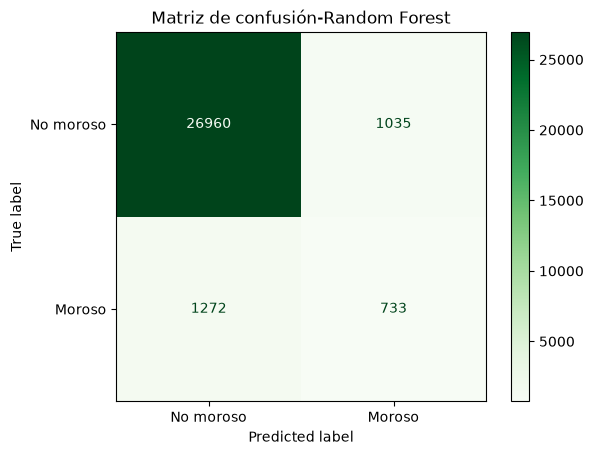

              precision    recall  f1-score   support

           0      0.955     0.963     0.959     27995
           1      0.415     0.366     0.389      2005

    accuracy                          0.923     30000
   macro avg      0.685     0.664     0.674     30000
weighted avg      0.919     0.923     0.921     30000



In [13]:
#matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No moroso","Moroso"]).plot(cmap="Greens")
plt.title("Matriz de confusión-Random Forest")
plt.show()
print(classification_report(y_test, y_pred, digits=3))